# ANALYSIS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("final_food_access_analysis_dataset.csv")
df.head()

,fips,State,County,Urban,LILATracts_1And10,HUNVFlag,SNAP_Participants,MedianIncome,PovertyPercent,TotalPopulation
0,17097,Illinois,Lake County,0.927632,0.052632,0.105263,62752,89427,7.9,701473
1,17051,Illinois,Fayette County,0.285714,0.714286,0.142857,,46650,17.2,21565
2,17107,Illinois,Logan County,0.375000,0.000000,0.375000,7680,57308,9.3,29003
3,17165,Illinois,Saline County,0.555556,0.333333,0.222222,9434,44090,21.1,23994
4,17127,Illinois,Massac County,0.500000,0.250000,0.250000,3849,47481,16.7,14219


**Cleaning and Setup**

In [15]:
#Removing empty data
key_cols = [
    "LILATracts_1And10",
    "HUNVFlag",
    "SNAP_Participants",
    "MedianIncome",
    "PovertyPercent",
    "TotalPopulation",
]

df = df.dropna(subset=key_cols)

#make sure numbers are valid
df = df[(df["MedianIncome"] > 0) & (df["TotalPopulation"] > 0)]
df[key_cols].dtypes
df['SNAP_Participants'] = pd.to_numeric(df['SNAP_Participants'], errors="coerce") #was an error with SNAP column being an object
df.head()

df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
Index: 2386 entries, 0 to 2411
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fips               2386 non-null   int64  
 1   State              2386 non-null   object 
 2   County             2386 non-null   object 
 3   Urban              2386 non-null   float64
 4   LILATracts_1And10  2386 non-null   float64
 5   HUNVFlag           2386 non-null   float64
 6   SNAP_Participants  2386 non-null   float64
 7   MedianIncome       2386 non-null   int64  
 8   PovertyPercent     2386 non-null   float64
 9   TotalPopulation    2386 non-null   int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 205.0+ KB


,fips,State,County,Urban,LILATracts_1And10,HUNVFlag,SNAP_Participants,MedianIncome,PovertyPercent,TotalPopulation
count,2386.000000,2386,2386,2386.000000,2386.000000,2386.000000,2386.000000,2386.000000,2386.000000,2.386000e+03
unique,NaN,32,1422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Texas,Cook County,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,254,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,32834.541911,NaN,NaN,0.359556,0.189959,0.235058,10837.370914,53499.415759,15.158676,1.400120e+05
std,13410.062123,NaN,NaN,0.318315,0.216655,0.220055,32745.294797,14179.205870,6.490837,5.540315e+05
min,10001.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,21504.000000,2.400000,9.800000e+01
25%,20181.500000,NaN,NaN,0.000000,0.000000,0.000000,1193.250000,44422.000000,10.500000,1.233250e+04
50%,28142.000000,NaN,NaN,0.333333,0.142857,0.200000,3236.500000,52087.000000,14.200000,2.776000e+04
75%,47032.500000,NaN,NaN,0.600000,0.285714,0.333333,8528.750000,60126.250000,18.600000,6.801350e+04


**Derive features for analysis**

In [17]:
#feature 1 - SNAP participation rate
df["SnapRate"] = df["SNAP_Participants"] / df["TotalPopulation"]

#feature 2 - Food access score (food desert + no vehicle/low access)
df["FoodAccessScore"] = df["LILATracts_1And10"] + df["HUNVFlag"]

#feature 3 - Hardship index: poverty + low income
df["HardshipIndex"] = df["PovertyPercent"] + (1 / df["MedianIncome"] * 100000)

df[["County", "State", "SnapRate", "FoodAccessScore", "HardshipIndex"]].head()

,County,State,SnapRate,FoodAccessScore,HardshipIndex
0,Lake County,Illinois,0.089457,0.157895,9.018231
2,Logan County,Illinois,0.264800,0.375000,11.044957
3,Saline County,Illinois,0.393182,0.555556,23.368088
4,Massac County,Illinois,0.270694,0.500000,18.806106
5,Cass County,Illinois,0.220443,0.000000,16.709381


**Group Counties into Groups by Income and SNAP reliance**

In [19]:
#income groups: Low, Middle, High
df["IncomeGroup"] = pd.qcut(
    df["MedianIncome"],
    q=3,
    labels=["Low income", "Middle income", "High income"]
)

#SNAP reliance groups
df["SnapGroup"] = pd.qcut(
    df["SnapRate"],
    q=3,
    labels=["Low SNAP reliance", "Medium SNAP reliance", "High SNAP reliance"]
)

df[["County", "State", "IncomeGroup", "SnapGroup"]].head()

,County,State,IncomeGroup,SnapGroup
0,Lake County,Illinois,High income,Medium SNAP reliance
2,Logan County,Illinois,High income,High SNAP reliance
3,Saline County,Illinois,Low income,High SNAP reliance
4,Massac County,Illinois,Middle income,High SNAP reliance
5,Cass County,Illinois,Middle income,High SNAP reliance


**Summary Tables**

In [22]:
income_summary = df.groupby("IncomeGroup")[
    ["SnapRate", "FoodAccessScore", "PovertyPercent", "HardshipIndex"]
].mean().round(3)

snap_summary = df.groupby("SnapGroup")[
    ["FoodAccessScore", "MedianIncome", "PovertyPercent", "HardshipIndex"]
].mean().round(3)

#create datasets for presentation
income_summary.to_csv("income_summary.csv")
snap_summary.to_csv("snap_summary.csv")

#display
income_summary, snap_summary

/var/folders/j9/hz867dcd691g3l1hyyzyz2r00000gn/T/ipykernel_60415/1590627268.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_summary = df.groupby("IncomeGroup")[
/var/folders/j9/hz867dcd691g3l1hyyzyz2r00000gn/T/ipykernel_60415/1590627268.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snap_summary = df.groupby("SnapGroup")[


(               SnapRate  FoodAccessScore  PovertyPercent  HardshipIndex
 IncomeGroup                                                            
 Low income        0.189            0.640          21.487         24.033
 Middle income     0.115            0.379          14.057         15.986
 High income       0.070            0.256           9.929         11.431,
                       FoodAccessScore  MedianIncome  PovertyPercent  \
 SnapGroup                                                             
 Low SNAP reliance               0.252     64171.067          10.361   
 Medium SNAP reliance            0.397     53502.678          14.190   
 High SNAP reliance              0.626     42837.913          20.918   
 
                       HardshipIndex  
 SnapGroup                            
 Low SNAP reliance            11.994  
 Medium SNAP reliance         16.108  
 High SNAP reliance           23.343  )

# MODELS

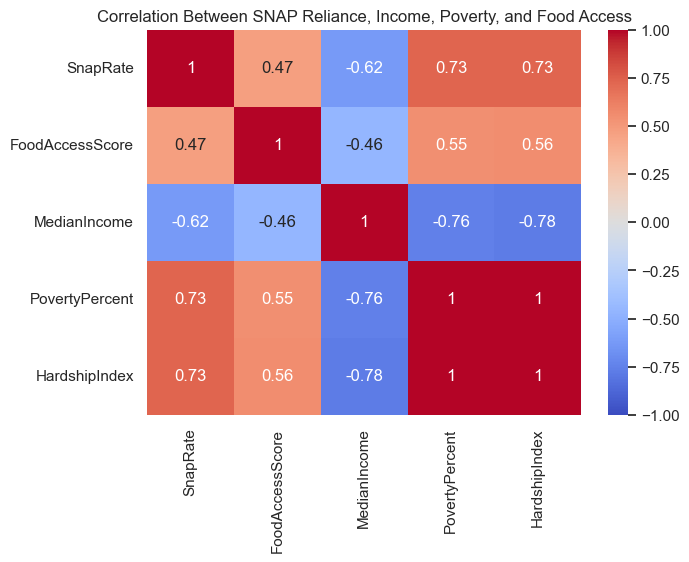

,SnapRate,FoodAccessScore,MedianIncome,PovertyPercent,HardshipIndex
SnapRate,1.000000,0.471217,-0.619926,0.727078,0.731697
FoodAccessScore,0.471217,1.000000,-0.459846,0.551797,0.555262
MedianIncome,-0.619926,-0.459846,1.000000,-0.757664,-0.776789
PovertyPercent,0.727078,0.551797,-0.757664,1.000000,0.999259
HardshipIndex,0.731697,0.555262,-0.776789,0.999259,1.000000


In [23]:
#Correlation Matrix
corr_vars = [
    "SnapRate",
    "FoodAccessScore",
    "MedianIncome",
    "PovertyPercent",
    "HardshipIndex"
]

corr_matrix = df[corr_vars].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Between SNAP Reliance, Income, Poverty, and Food Access")
plt.show()

corr_matrix

# VISUALIZATIONS

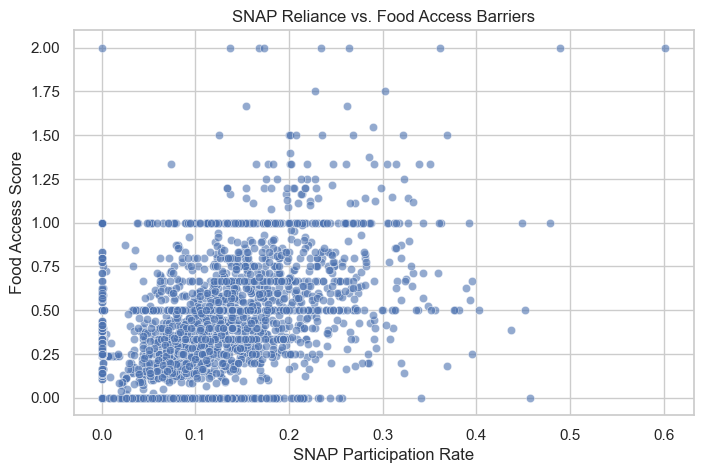

In [25]:
#scatterplot SNAP vs Food Access
sns.scatterplot(data=df, x="SnapRate", y="FoodAccessScore", alpha=0.6)
plt.title("SNAP Reliance vs. Food Access Barriers")
plt.xlabel("SNAP Participation Rate")
plt.ylabel("Food Access Score")
plt.show()

/var/folders/j9/hz867dcd691g3l1hyyzyz2r00000gn/T/ipykernel_60415/2676130228.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  income_bar = df.groupby("IncomeGroup")["FoodAccessScore"].mean()


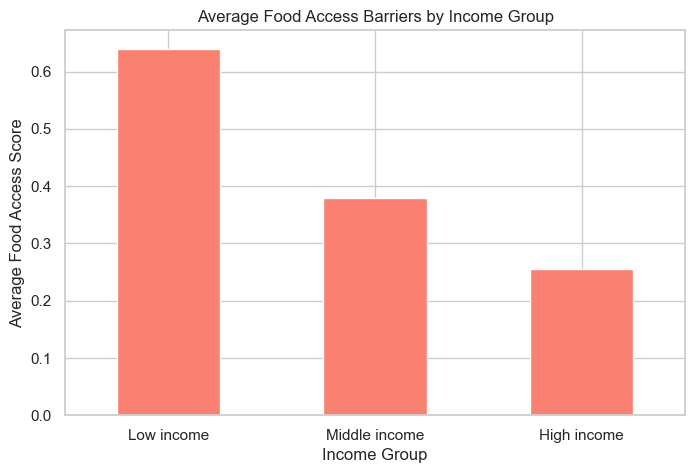

/var/folders/j9/hz867dcd691g3l1hyyzyz2r00000gn/T/ipykernel_60415/2676130228.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  snap_bar = df.groupby("SnapGroup")["FoodAccessScore"].mean()


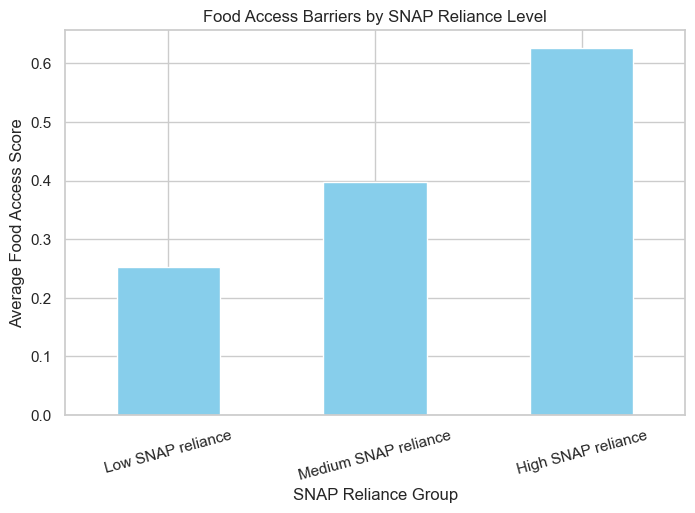

In [26]:
#Barchart - Income vs avg food access
income_bar = df.groupby("IncomeGroup")["FoodAccessScore"].mean()

income_bar.plot(kind="bar", color="salmon")
plt.title("Average Food Access Barriers by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Average Food Access Score")
plt.xticks(rotation=0)
plt.show()

#Barchar - SNAP reliance vs avg food access
snap_bar = df.groupby("SnapGroup")["FoodAccessScore"].mean()

snap_bar.plot(kind="bar", color="skyblue")
plt.title("Food Access Barriers by SNAP Reliance Level")
plt.xlabel("SNAP Reliance Group")
plt.ylabel("Average Food Access Score")
plt.xticks(rotation=15)
plt.show()

**Apply Results**

In [27]:
#Most vulnerable counties
df["VulnerabilityScore"] = (
    df["SnapRate"].rank(pct=True) +
    df["FoodAccessScore"].rank(pct=True) +
    df["HardshipIndex"].rank(pct=True)
)

top15 = df.sort_values("VulnerabilityScore", ascending=False).head(15)

top15[[
    "County", "State", "SnapRate", "FoodAccessScore",
    "MedianIncome", "PovertyPercent", "VulnerabilityScore"
]]

,County,State,SnapRate,FoodAccessScore,MedianIncome,PovertyPercent,VulnerabilityScore
1028,Todd County,South Dakota,0.489259,2.000000,24331,55.5,2.997904
592,East Carroll Parish,Louisiana,0.350761,1.333333,22346,44.6,2.976111
1325,Clay County,Kentucky,0.338963,1.333333,26840,36.6,2.967728
2224,Leflore County,Mississippi,0.322839,1.250000,26735,36.8,2.959137
2226,Claiborne County,Mississippi,0.304104,1.333333,29338,41.0,2.955993
768,Randolph County,Georgia,0.321526,1.500000,31699,32.9,2.954946
2150,Zavala County,Texas,0.301935,1.750000,34459,33.8,2.949916
558,Leslie County,Kentucky,0.290188,1.333333,31627,38.0,2.948868
2194,Holmes County,Mississippi,0.298585,1.200000,21504,42.4,2.947611
1479,Luna County,New Mexico,0.368683,1.500000,29360,27.7,2.945306


In [34]:
#averages for comparison
overall_means = df[[
    "SnapRate",
    "FoodAccessScore",
    "MedianIncome",
    "PovertyPercent",
    "HardshipIndex"
]].mean().round(4)

vulnerable_means = top15[[
    "SnapRate",
    "FoodAccessScore",
    "MedianIncome",
    "PovertyPercent",
    "HardshipIndex"
]].mean().round(4)

comparison_df = pd.DataFrame({
    "Overall Mean": overall_means,
    "Most Vulnerable Mean": vulnerable_means
})

comparison_df

,Overall Mean,Most Vulnerable Mean
SnapRate,0.1247,0.3230
FoodAccessScore,0.4250,1.4684
MedianIncome,53499.4158,28543.6667
PovertyPercent,15.1587,37.3933
HardshipIndex,17.1508,40.9691


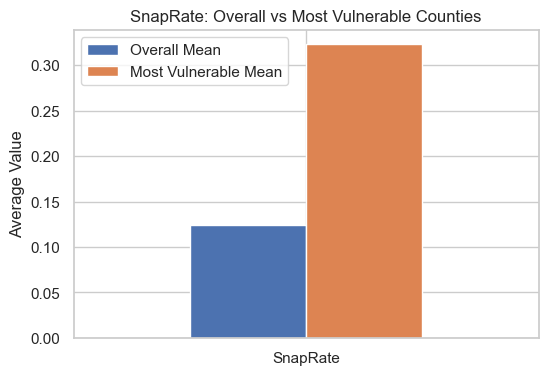

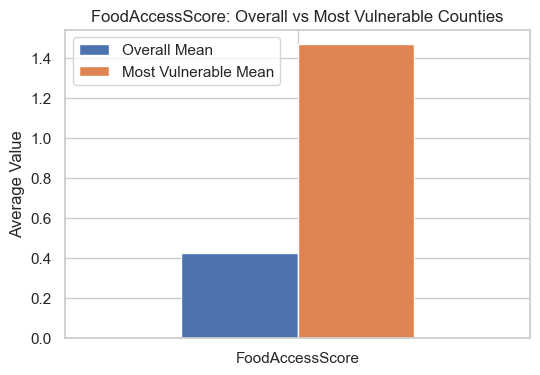

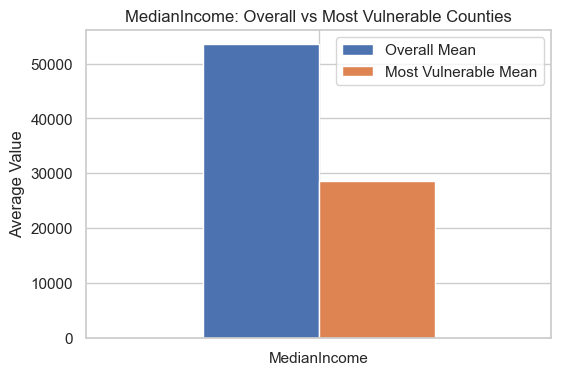

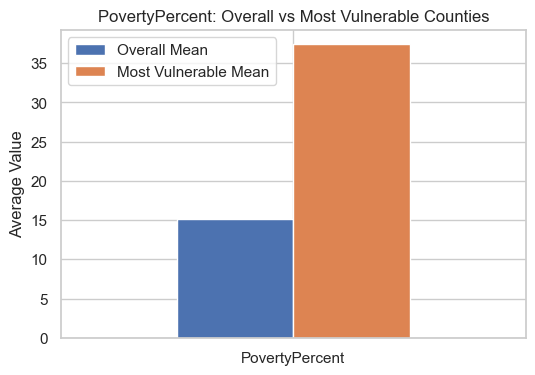

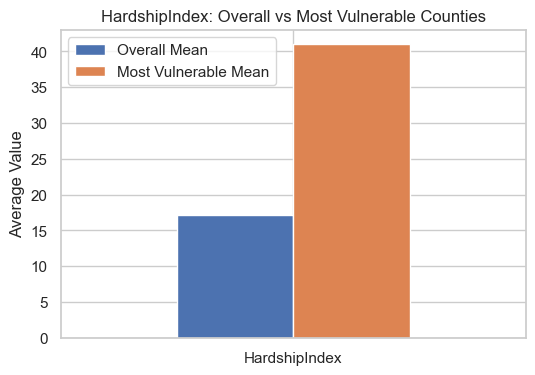

In [37]:
#Visualize this comparison
metrics = ["SnapRate", "FoodAccessScore", "MedianIncome", "PovertyPercent", "HardshipIndex"]

for m in metrics:
    comparison_df.loc[[m]].plot(kind="bar", figsize=(6,4), rot=0)
    plt.title(f"{m}: Overall vs Most Vulnerable Counties")
    plt.ylabel("Average Value")
    plt.show()